In [ ]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

In [ ]:
!wget https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz

--2026-04-01 04:48:25--  https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
Resolving archive.apache.org (archive.apache.org)... 65.108.204.189, 2a01:4f9:1a:a084::2
Connecting to archive.apache.org (archive.apache.org)|65.108.204.189|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 400395283 (382M) [application/x-gzip]
Saving to: ‘spark-3.5.0-bin-hadoop3.tgz’

spark-3.5.0-bin-had 100%[===================>] 381.85M  14.9MB/s    in 30s     

2026-04-01 04:48:55 (12.8 MB/s) - ‘spark-3.5.0-bin-hadoop3.tgz’ saved [400395283/400395283]



In [ ]:
!tar -xvf spark-3.5.0-bin-hadoop3.tgz

spark-3.5.0-bin-hadoop3/
spark-3.5.0-bin-hadoop3/kubernetes/
spark-3.5.0-bin-hadoop3/kubernetes/tests/
spark-3.5.0-bin-hadoop3/kubernetes/tests/pyfiles.py
spark-3.5.0-bin-hadoop3/kubernetes/tests/decommissioning.py
spark-3.5.0-bin-hadoop3/kubernetes/tests/autoscale.py
spark-3.5.0-bin-hadoop3/kubernetes/tests/python_executable_check.py
spark-3.5.0-bin-hadoop3/kubernetes/tests/worker_memory_check.py
spark-3.5.0-bin-hadoop3/kubernetes/tests/py_container_checks.py
spark-3.5.0-bin-hadoop3/kubernetes/tests/decommissioning_cleanup.py
spark-3.5.0-bin-hadoop3/kubernetes/dockerfiles/
spark-3.5.0-bin-hadoop3/kubernetes/dockerfiles/spark/
spark-3.5.0-bin-hadoop3/kubernetes/dockerfiles/spark/decom.sh
spark-3.5.0-bin-hadoop3/kubernetes/dockerfiles/spark/bindings/
spark-3.5.0-bin-hadoop3/kubernetes/dockerfiles/spark/bindings/R/
spark-3.5.0-bin-hadoop3/kubernetes/dockerfiles/spark/bindings/R/Dockerfile
spark-3.5.0-bin-hadoop3/kubernetes/dockerfiles/spark/bindings/python/
spark-3.5.0-bin-hadoop3/kubern

In [ ]:
!pip install -q findspark

In [ ]:
!ls

sample_data  spark-3.5.0-bin-hadoop3  spark-3.5.0-bin-hadoop3.tgz


In [ ]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

In [ ]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ClusteringDemo") \
    .getOrCreate()

print("Spark is ready 🚀")

Spark is ready 🚀


In [ ]:
spark

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mobile_Usage_Screentime_Dataset_.xlsx to Mobile_Usage_Screentime_Dataset_.xlsx


In [ ]:
!ls

Mobile_Usage_Screentime_Dataset_.xlsx  spark-3.5.0-bin-hadoop3
sample_data			       spark-3.5.0-bin-hadoop3.tgz


In [ ]:
import pandas as pd

df_pd = pd.read_excel("Mobile_Usage_Screentime_Dataset_.xlsx")
df_pd.head()

,UserID,Age,Gender,Daily_ScreenTime_Hours,SocialMedia_Min,Gaming_Min,Study_Min,Sleep_Hours,Device Type,Calls_Min,Messages_Sent,Battery_Drain_Percent
0,1,19,Female,9.98,229,105,267,5.6,Android,5,299,26
1,2,32,Male,10.91,167,157,182,6.2,iPhone,65,108,32
2,3,41,Female,4.84,230,146,12,5.6,iPhone,83,18,11
3,4,27,Male,2.66,55,144,278,6.7,Android,91,292,5
4,5,23,Male,3.89,126,119,216,4.2,iPhone,74,183,36


In [ ]:
df_pd.to_csv("mobile_usage.csv", index=False)

In [ ]:
df = spark.read.csv("mobile_usage.csv", header=True, inferSchema=True)
df.show()

+------+---+------+----------------------+---------------+----------+---------+-----------+-----------+---------+-------------+---------------------+
|UserID|Age|Gender|Daily_ScreenTime_Hours|SocialMedia_Min|Gaming_Min|Study_Min|Sleep_Hours|Device Type|Calls_Min|Messages_Sent|Battery_Drain_Percent|
+------+---+------+----------------------+---------------+----------+---------+-----------+-----------+---------+-------------+---------------------+
|     1| 19|Female|                  9.98|            229|       105|      267|        5.6|    Android|        5|          299|                   26|
|     2| 32|  Male|                 10.91|            167|       157|      182|        6.2|     iPhone|       65|          108|                   32|
|     3| 41|Female|                  4.84|            230|       146|       12|        5.6|     iPhone|       83|           18|                   11|
|     4| 27|  Male|                  2.66|             55|       144|      278|        6.7|    Andro

In [ ]:
df = df.select(
    "Daily_ScreenTime_Hours",
    "SocialMedia_Min",
    "Gaming_Min"
)

df = df.dropna()
df.show()

+----------------------+---------------+----------+
|Daily_ScreenTime_Hours|SocialMedia_Min|Gaming_Min|
+----------------------+---------------+----------+
|                  9.98|            229|       105|
|                 10.91|            167|       157|
|                  4.84|            230|       146|
|                  2.66|             55|       144|
|                  3.89|            126|       119|
|                  5.98|             15|        62|
|                 10.09|            108|        18|
|                 10.54|            133|        91|
|                  1.57|             46|        57|
|                  6.86|             33|        89|
|                  5.88|            102|       116|
|                  3.83|             55|        61|
|                  2.76|            190|        22|
|                  5.04|            104|       126|
|                  11.4|            108|       136|
|                  4.89|            197|       139|
|           

In [ ]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Daily_ScreenTime_Hours", "SocialMedia_Min", "Gaming_Min"],
    outputCol="features"
)

df = assembler.transform(df)

In [ ]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(k=3, seed=1)
model = kmeans.fit(df)

predictions = model.transform(df)

predictions.select(
    "Daily_ScreenTime_Hours",
    "SocialMedia_Min",
    "Gaming_Min",
    "prediction"
).show()

+----------------------+---------------+----------+----------+
|Daily_ScreenTime_Hours|SocialMedia_Min|Gaming_Min|prediction|
+----------------------+---------------+----------+----------+
|                  9.98|            229|       105|         1|
|                 10.91|            167|       157|         2|
|                  4.84|            230|       146|         2|
|                  2.66|             55|       144|         0|
|                  3.89|            126|       119|         2|
|                  5.98|             15|        62|         0|
|                 10.09|            108|        18|         1|
|                 10.54|            133|        91|         2|
|                  1.57|             46|        57|         0|
|                  6.86|             33|        89|         0|
|                  5.88|            102|       116|         2|
|                  3.83|             55|        61|         0|
|                  2.76|            190|        22|    

In [ ]:
centers = model.clusterCenters()

for i, center in enumerate(centers):
    print(f"Cluster {i}: {center}")

Cluster 0: [ 6.20869565 53.10869565 84.76086957]
Cluster 1: [  7.05833333 183.22222222  54.88888889]
Cluster 2: [  6.56552632 140.21052632 141.21052632]


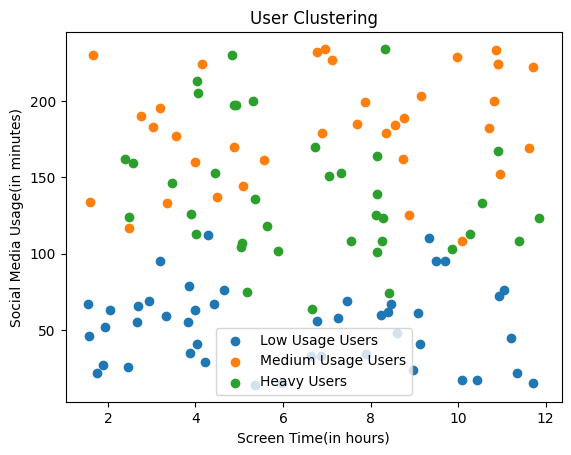

In [ ]:
import matplotlib.pyplot as plt

model.clusterCenters()
labels = {
    0: "Low Usage Users",
    1: "Medium Usage Users",
    2: "Heavy Users"
}

pdf = predictions.toPandas()

for cluster in sorted(pdf['prediction'].unique()):
    cluster_data = pdf[pdf['prediction'] == cluster]

    plt.scatter(
        cluster_data['Daily_ScreenTime_Hours'],
        cluster_data['SocialMedia_Min'],
        label=labels[cluster]
    )

plt.xlabel("Screen Time(in hours)")
plt.ylabel("Social Media Usage(in minutes)")
plt.title("User Clustering")

plt.legend()
plt.show()

In [ ]:
predictions.groupBy("prediction").count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1|   36|
|         2|   38|
|         0|   46|
+----------+-----+



In [ ]:
df_full = spark.read.csv("mobile_usage.csv", header=True, inferSchema=True)

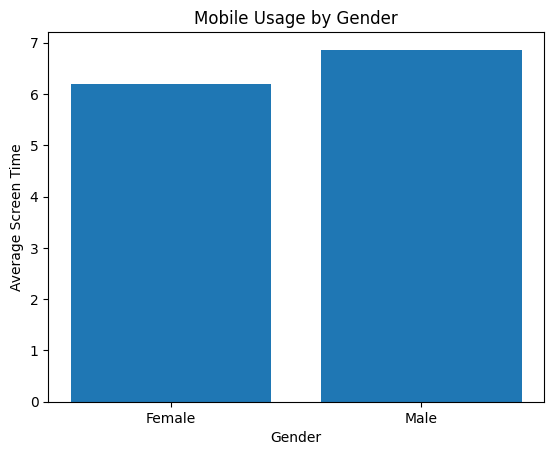

In [ ]:
pdf = df_full.groupBy("Gender").avg("Daily_ScreenTime_Hours").toPandas()

import matplotlib.pyplot as plt

plt.bar(pdf['Gender'], pdf['avg(Daily_ScreenTime_Hours)'])
plt.xlabel("Gender")
plt.ylabel("Average Screen Time")
plt.title("Mobile Usage by Gender")
plt.show()